### Import Modules

In [1]:
import pandas as pd,numpy as np,json
import getpass,os
from langchain.chat_models import init_chat_model
from ai_patterns_mining import parse_json_safe
from langchain.agents import create_agent
from pydantic import BaseModel,Field
from langchain.tools import tool
from langchain.agents.middleware import dynamic_prompt,ModelRequest
from langchain.agents.structured_output import ToolStrategy
from tqdm import tqdm
from time import time,sleep
from umap import UMAP
from sklearn.cluster import DBSCAN
from hdbscan import HDBSCAN
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances

/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-09 07:33:31.609771: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Initialize LLM

In [2]:
if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter API key for Google Gemini: ")

llm = init_chat_model("gemini-2.5-flash", model_provider="google_genai", temperature=1)

In [58]:
class SummarizationOutput(BaseModel):
    summary: str = Field(..., description="A concise two-sentence summary of the micro-architecture.")

@tool
def extract_representative_sentences(description: str) -> str:
    """
    Select the two most representative ORIGINAL sentences from the description.
    """
    print("Extracting representative sentences...")
    return f"""
From the description below, select exactly two sentences that best represent the core micro-architecture idea. 
Rules:
- Select only original sentences from the text.
- Do not rewrite, paraphrase, or summarize.
- Output ONLY the two sentences.

Description:
{description}
"""

@tool
def summarize_micro_architecture(description: str) -> str:
    """
    Summarize the micro-architecture in exactly two sentences.
    """
    print("Summarizing micro-architecture...")
    return f"""
Summarize the micro-architecture described below in exactly two sentences.
Rules:
- Output exactly 2 sentences.
- Focus on the architecture flow, components, and behavior.
- No bullet points, no extra text.

Description:
{description}

Two-sentence summary:
"""

@tool
def validate_extracted_sentences(text: str) -> str:
    """
    Validate extraction: must be exactly two sentences from the original text. if not, regenerate.
    """
    print("Validating extracted sentences...")
    return f"""Validate below text contains exactly two sentences:
    {text}
    """

@tool
def validate_two_sentence_summary(text: str) -> str:
    """
    Validate summary: must be exactly 2 sentences.
    """
    print("Validating two-sentence summary...")
    return f"""Validate below text contains exactly two sentences:
    {text}
    """

class DescriptionExtractionAgent:
    def __init__(self, llm):
        self.llm = llm
        self.agent = create_agent(
            llm,
            system_prompt=(
                "You are an extraction agent. Your job is to extract the two most "
                "representative original sentences from the description. After generation, "
                "you must validate and regenerate until valid."
            ),
            tools=[extract_representative_sentences, validate_extracted_sentences],
            response_format=ToolStrategy(SummarizationOutput)
        )

    def run(self, description: str):
        result = self.agent.invoke({"messages": [
                {"role": "user", "content": description}
            ]},recursion_limit=50)
        retry_count = 0
        while 'structured_response' not in result:
            if retry_count > 5:
                raise Exception("Max retries exceeded for description extraction.")
            sleep(1)
            result = self.agent.invoke({"messages": [
                {"role": "user", "content": description}
            ]})
            print(" - retrying description extraction...", end="\r")
            retry_count += 1
        return result['structured_response']

class MicroArchitectureSummaryAgent:
    def __init__(self, llm):
        self.llm = llm
        self.agent = create_agent(
            llm,
            system_prompt=(
                "You are a micro-architecture summarization agent. Your job is to produce a "
                "two-sentence summary that captures the architectural idea. You must validate "
                "your output and regenerate until valid."
            ),
            tools=[summarize_micro_architecture, validate_two_sentence_summary],
            response_format=ToolStrategy(SummarizationOutput)
        )

    def run(self, description: str):
        result = self.agent.invoke({"messages": [
                {"role": "user", "content": description}
            ]},recursion_limit=50)
        retry_count = 0
        while 'structured_response' not in result:
            if retry_count > 5:
                raise Exception("Max retries exceeded for description extraction.")
            sleep(1)
            result = self.agent.invoke({"messages": [
                {"role": "user", "content": description}
            ]})
            print(" - retrying micro-architecture summarization...", end="\r")
            retry_count += 1
        return result['structured_response']


In [ ]:
from typing import List, Dict, Any, Optional

class PatternVerificationOutput(BaseModel):
    correct_pattern: Optional[str] = Field(None, description="Outer pattern name selected or None.")
    l2_pattern: Optional[str] = Field(None, description="Best matching L2 pattern name or None.")
    score: int = Field(..., description="Confidence score 1-10.")
    explanation: str = Field(..., description="Concise justification (<=80 words).")

class PatternVerificationAgent:
    def __init__(self, llm, min_lines: int = 50):
        self.min_lines = min_lines
        self.agent = create_agent(
            llm,
            system_prompt=(
                "You are a pattern verification judge. You are given up to 3 candidate "
                "pattern groups (outer pattern -> list of L2 patterns). For a code snippet, "
                "decide which outer pattern and which L2 pattern is best supported by "
                "evidence. If none fit well, return None for both. Keep explanations brief."
            ),
            response_format=ToolStrategy(PatternVerificationOutput)
        )

    def _build_prompt(self, matched_patterns: List[Dict[str, List[Dict[str, Any]]]], code_snippet: str) -> str:
        return f"""
You are given up to 3 candidate pattern groups (already filtered as top-3).
Each element is a dict: <Pattern Name>: [<L2 pattern dicts>].
For the code snippet below, decide if any candidate clearly matches. If yes,
return the outer Pattern Name as correct_pattern and the strongest inner 'Pattern Name'
as l2_pattern. If nothing matches strongly, return None for both.

Candidates (JSON):
{json.dumps(matched_patterns, indent=2)}

Code snippet:
{code_snippet}

Return fields:
- correct_pattern: <outer pattern name or None>
- l2_pattern: <best L2 pattern name or None>
- score: 1-10 (evidence-based)
- explanation: <=80 words, cite concrete cues from code
"""

    def run(self, code_path: str, matched_patterns: List[Dict[str, List[Dict[str, Any]]]]):
        if not matched_patterns:
            raise ValueError("matched_patterns is empty; provide up to 3 patterns.")
        with open(code_path, "r") as f:
            code_snippet = f.read()
        if code_snippet.strip() == "" or code_snippet.count("\n") < self.min_lines:
            raise ValueError("Code snippet is empty or too short for verification.")
        prompt = self._build_prompt(matched_patterns, code_snippet)
        result = self.agent.invoke({"messages": [{"role": "user", "content": prompt}]})
        if "structured_response" not in result:
            raise ValueError("LLM did not return a structured response.")
        return result["structured_response"]

### Import data

In [6]:
community_data = pd.read_csv("/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/experiments-llm/results/pattern_embeddings/gemini_communities_embedding.csv")

descriptions = json.load(open('/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/notebooks/result/predicted_clusters_verification_results_with_descriptions.json'))
community_data['code_description'] = community_data['file'].apply(lambda x: descriptions.get(x, {}).get('code_summary', ""))
community_data = community_data[community_data['code_description'] != ""]

community_feature_cols = [i for i in community_data.columns if i.startswith('dim_')]
community_embeddings = community_data[community_feature_cols].to_numpy()

In [8]:
community_data.shape

(1679, 771)

### Clustering

In [24]:
scaler = StandardScaler()
community_embeddings_scaled = scaler.fit_transform(community_embeddings)
umap_model = UMAP(n_components=50,n_neighbors=15,metric='cosine', random_state=42)
umap_model_2d = UMAP(n_components=2,n_neighbors=15,metric='cosine', random_state=42)
community_embeddings_umap = umap_model.fit_transform(community_embeddings_scaled)
community_embeddings_umap_2d = umap_model_2d.fit_transform(community_embeddings_scaled)

/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [15]:
model = AgglomerativeClustering(
    n_clusters=100,
    metric='cosine',
    # distance_threshold=0.5,  # Set to None if you want to specify n_clusters
    linkage='average'   # other options: 'complete', 'average', 'single'
)
cluster_labels = model.fit_predict(community_embeddings_umap)
community_data['cluster_label'] = cluster_labels

for i in set(cluster_labels):
    cluster_size = community_data[community_data['cluster_label'] == i].shape[0]
    print(f"Cluster {i}: Size {cluster_size}")

Cluster 0: Size 30
Cluster 1: Size 24
Cluster 2: Size 17
Cluster 3: Size 32
Cluster 4: Size 37
Cluster 5: Size 37
Cluster 6: Size 48
Cluster 7: Size 27
Cluster 8: Size 13
Cluster 9: Size 64
Cluster 10: Size 13
Cluster 11: Size 22
Cluster 12: Size 21
Cluster 13: Size 14
Cluster 14: Size 34
Cluster 15: Size 17
Cluster 16: Size 10
Cluster 17: Size 23
Cluster 18: Size 21
Cluster 19: Size 21
Cluster 20: Size 39
Cluster 21: Size 11
Cluster 22: Size 18
Cluster 23: Size 15
Cluster 24: Size 27
Cluster 25: Size 10
Cluster 26: Size 10
Cluster 27: Size 9
Cluster 28: Size 14
Cluster 29: Size 5
Cluster 30: Size 14
Cluster 31: Size 43
Cluster 32: Size 12
Cluster 33: Size 38
Cluster 34: Size 30
Cluster 35: Size 46
Cluster 36: Size 14
Cluster 37: Size 5
Cluster 38: Size 12
Cluster 39: Size 8
Cluster 40: Size 14
Cluster 41: Size 38
Cluster 42: Size 12
Cluster 43: Size 15
Cluster 44: Size 24
Cluster 45: Size 11
Cluster 46: Size 28
Cluster 47: Size 24
Cluster 48: Size 6
Cluster 49: Size 13
Cluster 50: Siz

In [10]:
distances = pairwise_distances(community_embeddings_umap, metric='cosine')
print("Pairwise distances shape:", distances.shape)
print("Max distance:", np.max(distances))
print("Min distance:", np.min(distances))
print("Mean distance:", np.mean(distances))

Pairwise distances shape: (1679, 1679)
Max distance: 0.024873018
Min distance: 0.0
Mean distance: 0.0055268835


In [36]:
# dbscan_model = DBSCAN(eps=0.0001, min_samples=1, metric='cosine')
# cluster_labels = dbscan_model.fit_predict(community_embeddings_umap)
hdbscan_model = HDBSCAN(min_cluster_size=4,metric='precomputed' )
cluster_labels = hdbscan_model.fit_predict(distances.astype(np.float64))
community_data['cluster_label'] = cluster_labels

for label in np.unique(cluster_labels):
    print(f"\nCluster {label} summaries:")
    cluster_descriptions = community_data[community_data['cluster_label'] == label]['code_description'].tolist()
    combined_description = "\n".join(cluster_descriptions)
    # summary1 = summarize_code_description01(combined_description)
    # summary2 = summarize_code_description02(combined_description)
    # print(f"Summary 1: {summary1}")
    # print(f"Summary 2: {summary2}")
    print(f"Number of code snippets in cluster: {len(cluster_descriptions)}")


Cluster -1 summaries:
Number of code snippets in cluster: 472

Cluster 0 summaries:
Number of code snippets in cluster: 6

Cluster 1 summaries:
Number of code snippets in cluster: 11

Cluster 2 summaries:
Number of code snippets in cluster: 7

Cluster 3 summaries:
Number of code snippets in cluster: 9

Cluster 4 summaries:
Number of code snippets in cluster: 34

Cluster 5 summaries:
Number of code snippets in cluster: 14

Cluster 6 summaries:
Number of code snippets in cluster: 11

Cluster 7 summaries:
Number of code snippets in cluster: 16

Cluster 8 summaries:
Number of code snippets in cluster: 5

Cluster 9 summaries:
Number of code snippets in cluster: 9

Cluster 10 summaries:
Number of code snippets in cluster: 18

Cluster 11 summaries:
Number of code snippets in cluster: 6

Cluster 12 summaries:
Number of code snippets in cluster: 18

Cluster 13 summaries:
Number of code snippets in cluster: 8

Cluster 14 summaries:
Number of code snippets in cluster: 10

Cluster 15 summaries:
N

In [45]:
def detect_and_split_subclusters(data, beta_threshold=0.555, distance_metric="cosine"):
    from scipy.stats import skew, kurtosis
    from scipy.cluster.hierarchy import linkage, fcluster
    
    gamma = skew(data, axis=0).mean()

    kappa = kurtosis(data, axis=0, fisher=False).mean()

    beta = (gamma**2 + 1) / kappa

    two_clusters = beta > beta_threshold

    labels = np.zeros(len(data), dtype=int)

    if two_clusters:
        model = AgglomerativeClustering(
            n_clusters=2,
            metric=distance_metric,
            linkage="average"
        )
        labels = model.fit_predict(data)

    return {
        "beta": beta,
        "two_subclusters": two_clusters,
        "labels": labels
    }

from numpy.linalg import norm

def detect_centroid_outliers(data, z=2.0):
    centroid = np.mean(data, axis=0)
    
    centroid_norm = norm(centroid)
    if centroid_norm == 0:
        centroid_norm = 1e-8

    distances = []
    for x in data:
        dot = np.dot(x, centroid)
        denom = (norm(x) * centroid_norm) + 1e-8
        cosine_distance = 1 - (dot / denom)
        distances.append(cosine_distance)

    distances = np.array(distances)

    mean_d = distances.mean()
    std_d = distances.std()
    threshold = mean_d + z * std_d

    is_outlier = distances > threshold

    return {
        "distances": distances,
        "threshold": threshold,
        "is_outlier": is_outlier,
        "kept_indices": np.where(~is_outlier)[0],
        "outlier_indices": np.where(is_outlier)[0]
    }

def get_nearest_neighbors_to_centroid(data, centroid):
    distances = pairwise_distances(data, centroid.reshape(1, -1), metric='cosine').flatten()
    nearest_indices = np.argsort(distances)
    nearest_distances = distances[nearest_indices]
    return nearest_indices, nearest_distances

In [37]:
new_labels = community_data["cluster_label"].copy()
next_label = community_data["cluster_label"].max() + 1

for label in np.unique(cluster_labels):
    cluster_mask = community_data["cluster_label"] == label
    cluster_points = community_embeddings_umap[cluster_mask]

    result = detect_and_split_subclusters(cluster_points)

    # No split → skip
    if not result["two_subclusters"]:
        continue
    
    # Local labels {0,1}
    local_labels = result["labels"]

    # Map these local labels into new global labels
    global_label_1 = label          # keep original label for subcluster 0
    global_label_2 = next_label     # assign new label for subcluster 1
    next_label += 1

    mapped_labels = np.where(
        local_labels == 0,
        global_label_1,
        global_label_2
    )

    # Update the original data labels
    new_labels[cluster_mask] = mapped_labels

# Write back
community_data["cluster_label"] = new_labels

for label in np.unique(community_data["cluster_label"]):
    cluster_points = community_embeddings_umap[community_data["cluster_label"] == label]
    outlier_result = detect_centroid_outliers(cluster_points, z=2.0)
    num_outliers = np.sum(outlier_result["is_outlier"])
    print(f"Cluster {label}: Size {cluster_points.shape[0]}, Outliers detected: {num_outliers}")
    if num_outliers == 0:
        continue
    #Remove outliers by assigning them to a new cluster label
    outlier_indices = community_data[community_data["cluster_label"] == label].index[outlier_result["is_outlier"]]
    community_data.loc[outlier_indices, "cluster_label"] = -1

Cluster -1: Size 472, Outliers detected: 11
Cluster 0: Size 6, Outliers detected: 1
Cluster 1: Size 11, Outliers detected: 1
Cluster 2: Size 7, Outliers detected: 1
Cluster 3: Size 9, Outliers detected: 1
Cluster 4: Size 34, Outliers detected: 1
Cluster 5: Size 14, Outliers detected: 1
Cluster 6: Size 11, Outliers detected: 1
Cluster 7: Size 16, Outliers detected: 1
Cluster 8: Size 5, Outliers detected: 0
Cluster 9: Size 9, Outliers detected: 0
Cluster 10: Size 18, Outliers detected: 2
Cluster 11: Size 6, Outliers detected: 0
Cluster 12: Size 18, Outliers detected: 0
Cluster 13: Size 8, Outliers detected: 0
Cluster 14: Size 10, Outliers detected: 1
Cluster 15: Size 5, Outliers detected: 0
Cluster 16: Size 14, Outliers detected: 0
Cluster 17: Size 14, Outliers detected: 0
Cluster 18: Size 12, Outliers detected: 1
Cluster 19: Size 21, Outliers detected: 1
Cluster 20: Size 9, Outliers detected: 1
Cluster 21: Size 3, Outliers detected: 0
Cluster 22: Size 7, Outliers detected: 0
Cluster 23:

In [38]:
for label in np.unique(community_data["cluster_label"]):
    print(f"Cluster size for label {label}: {community_data[community_data['cluster_label'] == label].shape[0]}")

Cluster size for label -1: 533
Cluster size for label 0: 5
Cluster size for label 1: 10
Cluster size for label 2: 6
Cluster size for label 3: 8
Cluster size for label 4: 33
Cluster size for label 5: 13
Cluster size for label 6: 10
Cluster size for label 7: 15
Cluster size for label 8: 5
Cluster size for label 9: 9
Cluster size for label 10: 16
Cluster size for label 11: 6
Cluster size for label 12: 18
Cluster size for label 13: 8
Cluster size for label 14: 9
Cluster size for label 15: 5
Cluster size for label 16: 14
Cluster size for label 17: 14
Cluster size for label 18: 11
Cluster size for label 19: 20
Cluster size for label 20: 8
Cluster size for label 21: 3
Cluster size for label 22: 7
Cluster size for label 23: 7
Cluster size for label 24: 12
Cluster size for label 25: 4
Cluster size for label 26: 15
Cluster size for label 27: 6
Cluster size for label 28: 14
Cluster size for label 29: 5
Cluster size for label 30: 10
Cluster size for label 31: 10
Cluster size for label 32: 6
Cluste

In [61]:
extraction_agent = DescriptionExtractionAgent(llm)
summary_agent = MicroArchitectureSummaryAgent(llm)

code_cluster_descriptions_file = '/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/notebooks/result/descriptions_for_clustered_communities_v4-hdbscan.json'
if os.path.exists(code_cluster_descriptions_file):
    code_cluster_descriptions = json.load(open(code_cluster_descriptions_file))
else:
    code_cluster_descriptions = {}
for label in np.unique(community_data['cluster_label']):
    if label == -1:
        continue
    print(f"\nCluster {label} summaries:")
    if str(label) in code_cluster_descriptions:
        print(" - Using cached summaries.")
        continue

    cluster_mask = community_data['cluster_label'] == label
    cluster_points = community_embeddings_umap[cluster_mask]
    
    centroid = np.mean(cluster_points, axis=0)
    
    nearest_local_idx, nearest_distances = get_nearest_neighbors_to_centroid(
        cluster_points, centroid
    )

    cluster_global_indices = np.where(cluster_mask)[0]
    nearest_global_idx = cluster_global_indices[nearest_local_idx]
    
    top3_idx = nearest_global_idx[:3]

    print("Top-3 distances:", nearest_distances[:3])
    print("Top-3 indices:", top3_idx)

    # Pull descriptions
    cluster_descriptions = community_data.iloc[top3_idx]['code_description'].tolist()

    
    print(f"Number of code snippets in cluster: {len(cluster_descriptions)}")
    combined_description = "\n\n".join(cluster_descriptions)
    summary1 = extraction_agent.run(combined_description)
    summary2 = summary_agent.run(combined_description)

    std_dev = np.std(nearest_distances)
    mean_dist = np.mean(nearest_distances)

    alpha = std_dev / (mean_dist + 1e-8)
    
    code_cluster_descriptions[str(label)] = {
        "cluster_id": 'cluster_'+str(label),
        "number_of_instances": cluster_points.shape[0],
        "prompt_01_desc": summary1.summary,
        "prompt_02_desc": summary2.summary,
        "descriptions": "\n\n".join(cluster_descriptions),
        "alpha": f"{alpha:.4f}"
    }
    json.dump(code_cluster_descriptions, open(code_cluster_descriptions_file, 'w'), indent=4)


Cluster 0 summaries:
 - Using cached summaries.

Cluster 1 summaries:
 - Using cached summaries.

Cluster 2 summaries:
 - Using cached summaries.

Cluster 3 summaries:
 - Using cached summaries.

Cluster 4 summaries:
 - Using cached summaries.

Cluster 5 summaries:
 - Using cached summaries.

Cluster 6 summaries:
 - Using cached summaries.

Cluster 7 summaries:
 - Using cached summaries.

Cluster 8 summaries:
 - Using cached summaries.

Cluster 9 summaries:
 - Using cached summaries.

Cluster 10 summaries:
 - Using cached summaries.

Cluster 11 summaries:
 - Using cached summaries.

Cluster 12 summaries:
 - Using cached summaries.

Cluster 13 summaries:
 - Using cached summaries.

Cluster 14 summaries:
 - Using cached summaries.

Cluster 15 summaries:
 - Using cached summaries.

Cluster 16 summaries:
 - Using cached summaries.

Cluster 17 summaries:
 - Using cached summaries.

Cluster 18 summaries:
 - Using cached summaries.

Cluster 19 summaries:
 - Using cached summaries.

Cluster 2

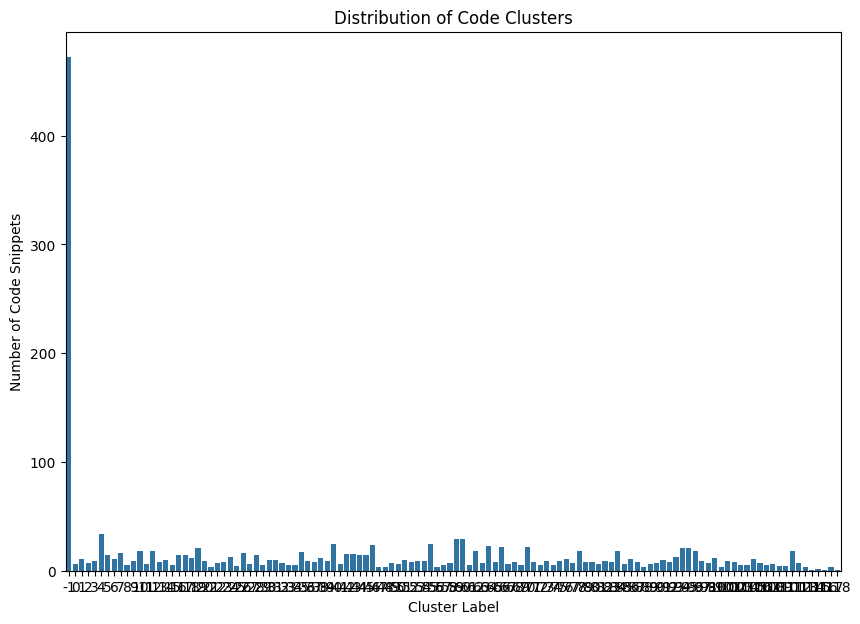

In [31]:
plt.figure(figsize=(10, 7))
sns.countplot(x='cluster_label', data=community_data)
plt.title('Distribution of Code Clusters')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Code Snippets')
plt.show()

In [46]:
import numpy as np
import hdbscan

# normalize (recommended)
emb = community_embeddings_umap / np.linalg.norm(
    community_embeddings_umap, axis=1, keepdims=True
)

clusterer = hdbscan.HDBSCAN(
    metric='cosine',
    algorithm='brute',             # MUST for cosine
    approx_min_span_tree=False,    # MUST disable sklearn tree path
    min_cluster_size=4
)

labels = clusterer.fit_predict(emb)


/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


TypeError: Unknown algorithm type brute specified

In [63]:
json.dump([i for i in code_cluster_descriptions.values()],open("/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/notebooks/result/descriptions_for_clustered_communities_v4-hdbscan-list.json",'w'),)